In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

In [2]:
df = pd.read_csv("../datasets/forecasting/apple_stock.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0
1,2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0
2,2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0
3,2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0
4,2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0


In [3]:
print(df.shape)

df.info()

(526, 8)
<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          526 non-null    str    
 1   Open          526 non-null    float64
 2   High          526 non-null    float64
 3   Low           526 non-null    float64
 4   Close         526 non-null    float64
 5   Volume        526 non-null    int64  
 6   Dividends     526 non-null    float64
 7   Stock Splits  526 non-null    float64
dtypes: float64(6), int64(1), str(1)
memory usage: 33.0 KB


In [4]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0
1,2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0
2,2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0
3,2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0
4,2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0


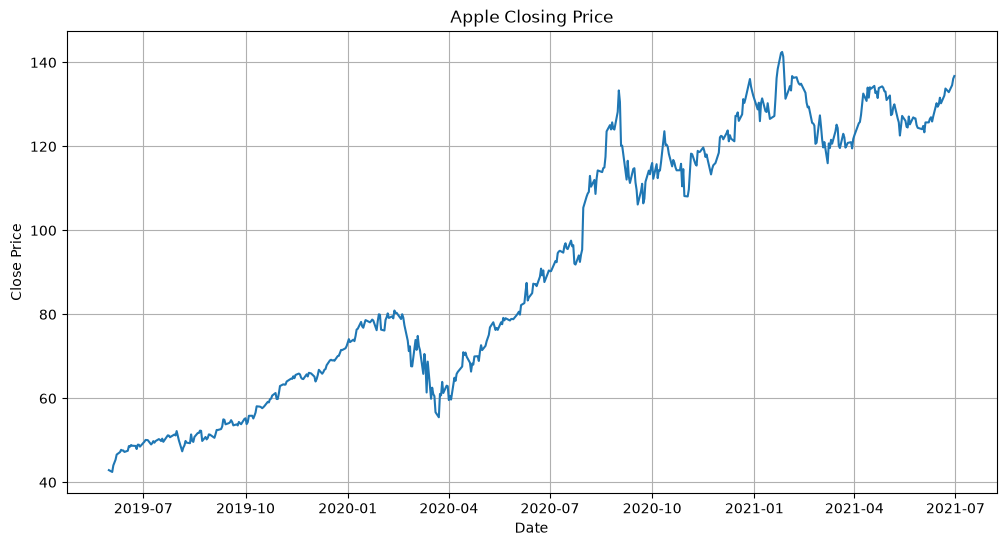

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Close"],
)

plt.title("Apple Closing Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.grid(True)

plt.show()

In [7]:
df["Day"] = np.arange(len(df))

In [8]:
X = df[["Day"]]

y = df["Close"]

In [9]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [10]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(420, 1)
(106, 1)
(420,)
(106,)


In [11]:
model = LinearRegression()

model.fit(
    X_train,
    y_train,
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.22]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Day']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.45
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred,
)

mse = mean_squared_error(
    y_test,
    y_pred,
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred,
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 12.4079
RMSE: 13.6530
R²  : -6.0617


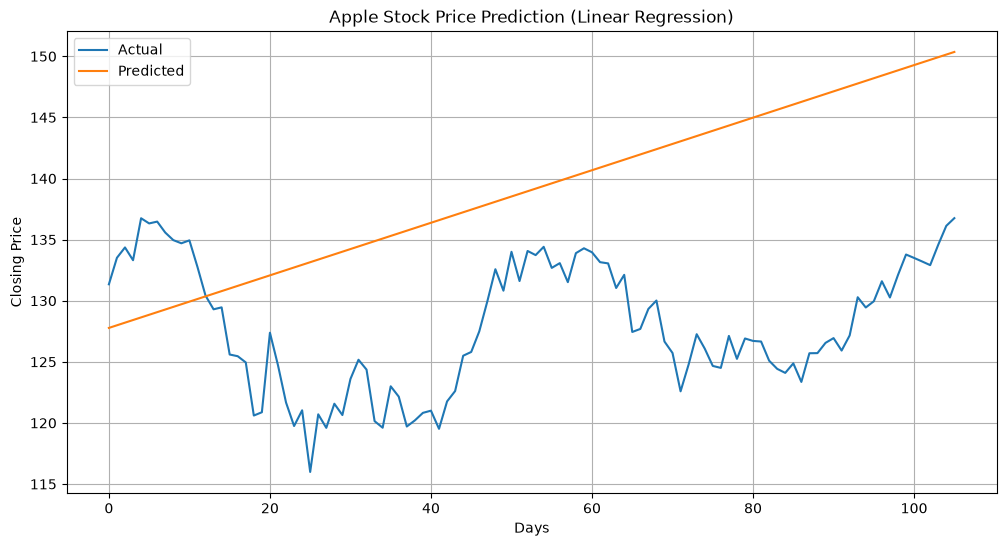

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
)

plt.plot(
    y_pred,
    label="Predicted",
)

plt.title("Apple Stock Price Prediction (Linear Regression)")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [15]:
joblib.dump(
    model,
    "../trained_models/linear_forecast_model.pkl",
)

['../trained_models/linear_forecast_model.pkl']

In [16]:
import os

os.path.exists(
    "../trained_models/linear_forecast_model.pkl",
)

True

In [17]:
from statsmodels.tsa.arima.model import ARIMA

In [18]:
arima = ARIMA(
    y_train,
    order=(5,1,0)
)

arima_model = arima.fit()

In [19]:
forecast = arima_model.forecast(
    steps=len(y_test)
)

In [20]:
mae = mean_absolute_error(
    y_test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast
    )
)

r2 = r2_score(
    y_test,
    forecast
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 8.8992
RMSE: 10.2745
R²  : -2.9992


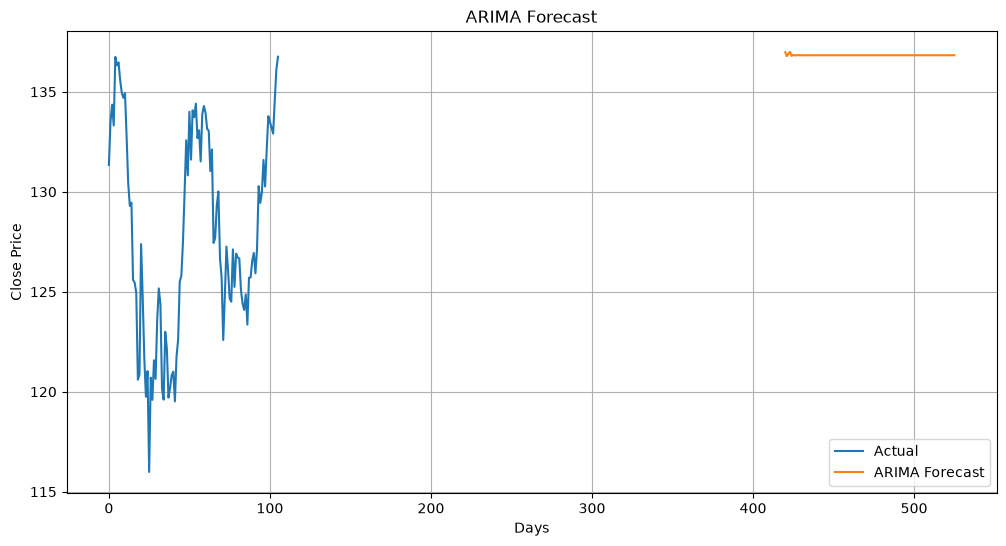

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast")

plt.xlabel("Days")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

In [22]:
joblib.dump(
    arima_model,
    "../trained_models/arima_forecast_model.pkl",
)

['../trained_models/arima_forecast_model.pkl']

In [23]:
import warnings

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [24]:
best_aic = float("inf")

best_order = None

best_model = None

for p in range(0, 6):

    for d in range(0, 3):

        for q in range(0, 6):

            try:

                model = ARIMA(
                    y_train,
                    order=(p, d, q),
                )

                result = model.fit()

                if result.aic < best_aic:

                    best_aic = result.aic

                    best_order = (p, d, q)

                    best_model = result

            except Exception:

                continue

In [25]:
print("Best Order:", best_order)

print("Best AIC:", best_aic)

Best Order: (4, 1, 4)
Best AIC: 1814.224340086796


In [26]:
forecast = best_model.forecast(
    steps=len(y_test)
)

In [27]:
mae = mean_absolute_error(
    y_test,
    forecast,
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast,
    )
)

r2 = r2_score(
    y_test,
    forecast,
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 9.1962
RMSE: 10.5544
R²  : -3.2201


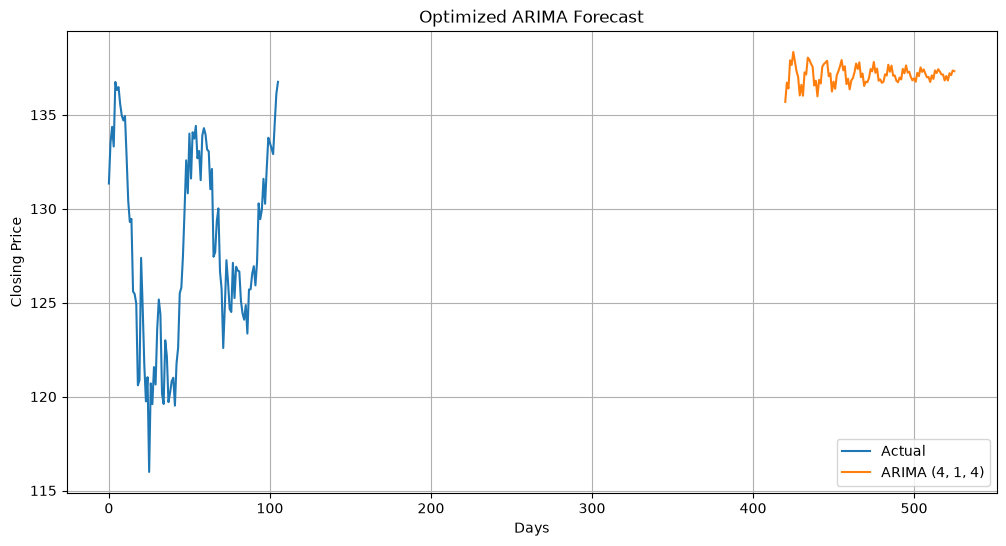

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
)

plt.plot(
    forecast,
    label=f"ARIMA {best_order}",
)

plt.title("Optimized ARIMA Forecast")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
joblib.dump(
    best_model,
    "../trained_models/arima_forecast_model.pkl",
)

['../trained_models/arima_forecast_model.pkl']

In [32]:
from prophet import Prophet

In [33]:
prophet_df = df[["Date", "Close"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2019-05-31,42.897572
1,2019-06-03,42.463867
2,2019-06-04,44.017353
3,2019-06-05,44.727940
4,2019-06-06,45.384624


In [34]:
split = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split]

test = prophet_df.iloc[split:]

In [35]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

model.fit(train)

15:15:14 - cmdstanpy - INFO - Chain [1] start processing
15:15:15 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="D",
)

In [37]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
521,2021-05-10,139.614560,124.816741,136.904614,135.040815,144.169454,-8.729367,-8.729367,-8.729367,2.373543,2.373543,2.373543,-11.102910,-11.102910,-11.102910,0.0,0.0,0.0,130.885193
522,2021-05-11,139.766706,125.150319,137.124315,135.127258,144.407743,-8.436894,-8.436894,-8.436894,2.443015,2.443015,2.443015,-10.879909,-10.879909,-10.879909,0.0,0.0,0.0,131.329812
523,2021-05-12,139.918852,125.758840,137.948548,135.186975,144.651806,-8.022516,-8.022516,-8.022516,2.648690,2.648690,2.648690,-10.671207,-10.671207,-10.671207,0.0,0.0,0.0,131.896336
524,2021-05-13,140.070999,126.049299,137.783883,135.289139,144.898446,-8.034968,-8.034968,-8.034968,2.445288,2.445288,2.445288,-10.480255,-10.480255,-10.480255,0.0,0.0,0.0,132.036031
525,2021-05-14,140.223145,125.765291,138.224801,135.379573,145.109054,-8.142302,-8.142302,-8.142302,2.167738,2.167738,2.167738,-10.310039,-10.310039,-10.310039,0.0,0.0,0.0,132.080844


In [38]:
pred = forecast["yhat"].tail(len(test)).values

actual = test["y"].values

In [39]:
mae = mean_absolute_error(actual, pred)

rmse = np.sqrt(mean_squared_error(actual, pred))

r2 = r2_score(actual, pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 7.3527
RMSE: 9.8553
R²  : -2.6795


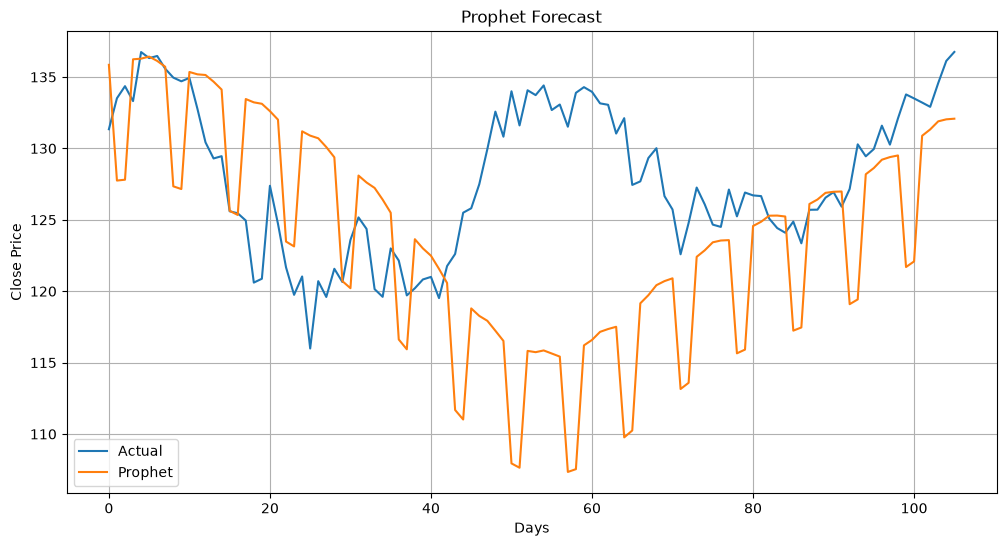

In [40]:
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")

plt.plot(pred, label="Prophet")

plt.title("Prophet Forecast")

plt.xlabel("Days")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

In [41]:
joblib.dump(
    model,
    "../trained_models/prophet_forecast_model.pkl",
)

['../trained_models/prophet_forecast_model.pkl']